# XOPT - INTERPRETABLE METAHEURISTICS FOR COMBINATORIAL OPTIMIZATION

## FREQUENT ITEMSET MINING

This notebook applies frequent itemset mining to long-term memory solutions generated by `pymedian.solve_pmedian` for the `pmed11.txt` instance. Each solution is treated as a transaction and each selected facility is treated as an item.

### SETTING THE ENVIRONMENT

In [1]:
import numpy    as np
import pandas   as pd
import networkx as nx
import seaborn  as sns
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori  as mlxtend_apriori
from mlxtend.frequent_patterns import fpgrowth as mlxtend_fpgrowth

from IPython.display import display

from lib import ensure_project_on_path      , \
                instances_dir               , \
                best_facilities_from_summary, \
                long_term_memory_to_arrays
from lib import best_solution as find_best_solution

In [2]:
ROOT = ensure_project_on_path()


sns.set_theme(style='whitegrid', context='notebook')

plt.rcParams['figure.dpi'] = 110

### LOAD SOLUTIONS

In [3]:
import pymedian


INSTANCE_NAME = 'pmed11.txt'

RESTARTS = 8
MAX_ITER = 25
FACTOR   = 2

In [4]:
instance_path = instances_dir(ROOT) / INSTANCE_NAME

summary, details = pymedian.solve_pmedian(
    str(instance_path),
    restarts=RESTARTS,
    max_iter=MAX_ITER,
    factor  =FACTOR  ,
)


print(f"Instance {summary['instance'][:-4]} ({summary['p']}-{summary['n']})")

print()

print(f"  K-Medoids ({summary['kmedoids_cost']}): {summary['medoids'          ][:10]}")
print(f"  TSPMED    ({summary['tspmed_cost'  ]}): {summary['tspmed_facilities'][:10]}")

Instance /home/rei-luisinho/xopt/instances/pmed11 (5-300)

  K-Medoids (7696.0): [98, 201, 167, 24, 31]
  TSPMED    (7696.0): [98, 201, 167, 24, 31]


In [5]:
solution_arrays = long_term_memory_to_arrays(
    details['long_term_memory'],
    summary['n'               ],
)

X     = solution_arrays.X.astype(bool)
costs = solution_arrays.costs

best_memory_solution = find_best_solution          (details['long_term_memory'])
best_facilities      = best_facilities_from_summary(summary)


print(f"Transactions from long-term memory : {len(X)}"      )
print(f"Items per transaction              : {summary['p']}")

print()

print(f"Best memory solution cost : {best_memory_solution.cost}")
print(f"Cost range                : [{int(costs.min())}, {int(costs.max())}]")

Transactions from long-term memory : 799
Items per transaction              : 5

Best memory solution cost : 7696.0
Cost range                : [7696, 7843]


### FACILITY FREQUENCY

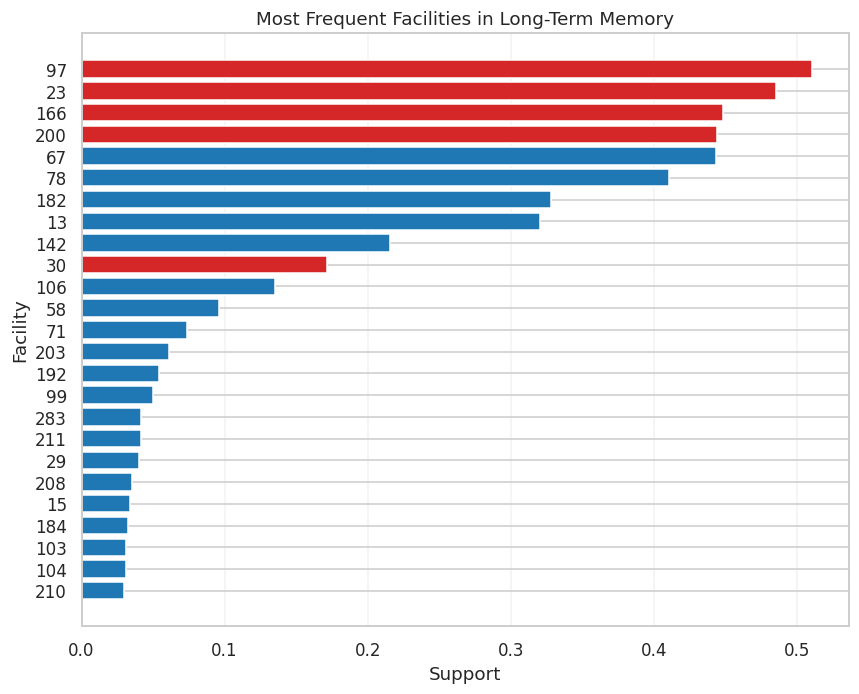

In [6]:
facility_counts = X.sum(axis=0).astype(int)

facility_df = pd.DataFrame(
    {
        'facility' : np.arange(X.shape[1])   ,
        'count'    : facility_counts         ,
        'support'  : facility_counts / len(X),
        'is_tspmed': [
            idx in best_facilities
            for idx in range(X.shape[1])
        ],
    }
)

top_facilities = facility_df.sort_values('count', ascending=False).head(25).iloc[::-1]
colors         = top_facilities['is_tspmed'].map({True: 'tab:red', False: 'tab:blue'})


fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(
    top_facilities['facility'].astype(str),
    top_facilities['support' ]            ,
    color=colors,
)

ax.set_title ('Most Frequent Facilities in Long-Term Memory')
ax.set_xlabel('Support' )
ax.set_ylabel('Facility')
ax.grid(axis='x', alpha=0.25)

plt.show()

### APRIORI AND FP-GROWTH

In [7]:
def minimum_support_count(min_support, n_transactions):
    if 0 < min_support < 1:
        return max(1, int(np.ceil(min_support * n_transactions)))

    return max(1, int(min_support))


def frequent_itemset_counts(miner, transactions_df, min_support=0.08, max_len=4):
    n_transactions = len                  (transactions_df)
    min_count      = minimum_support_count(min_support, n_transactions)

    if min_count > n_transactions:
        return {}

    frequent_df = miner(
        transactions_df,
        min_support =min_count / n_transactions,
        use_colnames=True   ,
        max_len     =max_len,
    )

    return {
        frozenset(int(item) for item in row.itemsets) : int(round(row.support * n_transactions))
        for row in frequent_df.itertuples(index=False)
    }


def itemset_label(itemset):
    return '{' + ', '.join(f'F{item}' for item in sorted(itemset)) + '}'


def itemset_mask(X_in, itemset):
    cols = list(sorted(itemset))

    if not cols:
        return np.ones(X_in.shape[0], dtype=bool)

    return X_in[:, cols].all(axis=1)


def itemset_metrics(frequent_counts, X_in, costs_in, n_best):
    rows = []
    n    = len(X_in)

    for itemset, count in frequent_counts.items():
        mask = itemset_mask(X_in, itemset)

        support      = count / n
        best_support = mask[:n_best].mean()
        best_lift    = best_support / support if support > 0 else np.nan

        rows.append(
            {
                'itemset'      : itemset               ,
                'label'        : itemset_label(itemset),

                'size'         : len(itemset),
                'support_count': int(count  ),
                'support'      : float(support     ),
                'best_support' : float(best_support),
                'best_lift'    : float(best_lift   ),

                'mean_cost'    : float(costs_in[mask].mean()),
                'min_cost'     : float(costs_in[mask].min ()),
            }
        )

    columns = [
        'itemset'      ,
        'label'        ,
        'size'         ,
        'support_count',
        'support'      ,
        'best_support' ,
        'best_lift'    ,
        'mean_cost'    ,
        'min_cost'     ,
    ]

    return pd.DataFrame(rows, columns=columns)

### MINING FREQUENT ITEMSETS

In [8]:
MIN_SUPPORT      = 0.08
MAX_ITEMSET_SIZE = min(4, summary['p'])
N_BEST_SOLUTIONS = max(5, int(np.ceil(0.10 * len(X))))


transactions_df = pd.DataFrame(X, columns=np.arange(X.shape[1]))

apriori_counts = frequent_itemset_counts(
    mlxtend_apriori,
    transactions_df,
    min_support=MIN_SUPPORT     ,
    max_len    =MAX_ITEMSET_SIZE,
)
fpgrowth_counts = frequent_itemset_counts(
    mlxtend_fpgrowth,
    transactions_df ,
    min_support=MIN_SUPPORT     ,
    max_len    =MAX_ITEMSET_SIZE,
)

apriori_df  = itemset_metrics(apriori_counts , X, costs, N_BEST_SOLUTIONS)
fpgrowth_df = itemset_metrics(fpgrowth_counts, X, costs, N_BEST_SOLUTIONS)

itemsets_df = fpgrowth_df.sort_values(
    ['support', 'size', 'best_lift'],
    ascending  =[False, True, False],
).reset_index(drop=True)

comparison_df = pd.DataFrame(
    [
        {
            'algorithm' : 'Apriori',
            'itemsets'  : len(apriori_counts),
            'max_size'  : max(map(len, apriori_counts), default=0),
        },
        {
            'algorithm' : 'FP-growth',
            'itemsets'  : len(fpgrowth_counts),
            'max_size'  : max(map(len, fpgrowth_counts), default=0),
        },
    ]
)


same_itemsets = apriori_counts == fpgrowth_counts

print(f'Minimum support       : {MIN_SUPPORT:.0%}'                           )
print(f'Minimum support count : {minimum_support_count(MIN_SUPPORT, len(X))}')
print(f'Max itemset size      : {MAX_ITEMSET_SIZE}')

print()

print(f'Algorithms agree : {same_itemsets}')

Minimum support       : 8%
Minimum support count : 64
Max itemset size      : 4

Algorithms agree : True


In [9]:
display(comparison_df)

,algorithm,itemsets,max_size
0,Apriori,54,3
1,FP-growth,54,3


In [10]:
display(
    itemsets_df[
        [
            'label'        ,
            'size'         ,
            'support_count',
            'support'      ,
            'best_support' ,
            'best_lift'    ,
            'mean_cost'    ,
        ]
    ].head(20).round(4)
)

,label,size,support_count,support,best_support,best_lift,mean_cost
0,{F97},1,408,0.5106,0.4875,0.9547,7795.3799
1,{F23},1,388,0.4856,0.6000,1.2356,7793.6727
2,{F166},1,358,0.4481,0.5125,1.1438,7793.6117
3,{F200},1,355,0.4443,0.5125,1.1535,7793.0085
4,{F67},1,354,0.4431,0.4875,1.1003,7794.9435
5,{F78},1,328,0.4105,0.4875,1.1875,7793.6311
6,{F182},1,262,0.3279,0.3250,0.9911,7793.9237
7,{F13},1,256,0.3204,0.2625,0.8193,7797.5430
8,"{F23, F97}",2,199,0.2491,0.2875,1.1543,7793.3116
9,"{F97, F200}",2,182,0.2278,0.2625,1.1524,7793.0385


In [11]:
display(
    itemsets_df.loc[
        itemsets_df['size'] > 2,
        [
            'label'        ,
            'size'         ,
            'support_count',
            'support'      ,
            'best_support' ,
            'best_lift'    ,
            'mean_cost'    ,
        ]
    ].head(20).round(4)
)

,label,size,support_count,support,best_support,best_lift,mean_cost
36,"{F23, F97, F200}",3,87,0.1089,0.1375,1.2628,7791.2414
41,"{F23, F78, F97}",3,77,0.0964,0.1375,1.4268,7789.7273
43,"{F23, F97, F166}",3,76,0.0951,0.1500,1.5770,7785.9737
44,"{F97, F166, F200}",3,75,0.0939,0.1500,1.5980,7787.7867
45,"{F23, F67, F166}",3,71,0.0889,0.1375,1.5474,7788.9296
46,"{F23, F67, F78}",3,69,0.0864,0.1500,1.7370,7790.2174
48,"{F23, F67, F200}",3,68,0.0851,0.1250,1.4688,7788.3235
49,"{F67, F166, F200}",3,68,0.0851,0.1125,1.3219,7789.0294
51,"{F13, F23, F97}",3,65,0.0814,0.0750,0.9219,7792.0923
52,"{F78, F97, F200}",3,64,0.0801,0.1125,1.4045,7787.8906


### MOST SUPPORTED ITEMSETS

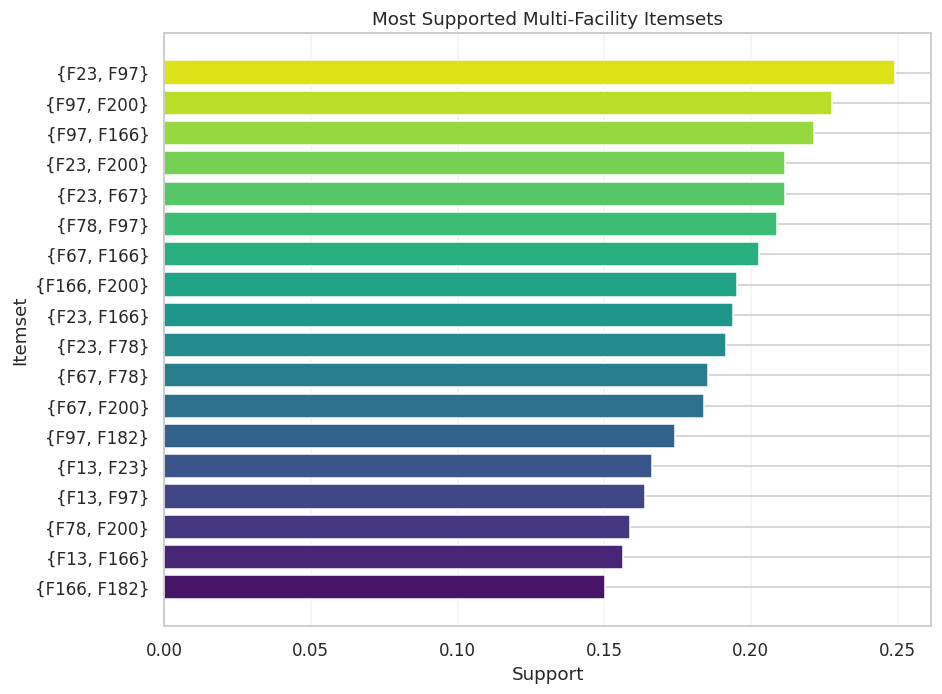

In [12]:
top_supported = itemsets_df[
    itemsets_df['size'] >= 2
].head(18).iloc[::-1]

if top_supported.empty:
    print('No multi-facility itemsets were found. Lower MIN_SUPPORT to inspect rarer patterns.')
else:
    fig, ax = plt.subplots(figsize=(9, 7))

    colors = sns.color_palette('viridis', len(top_supported))

    ax.barh(
        top_supported['label'  ],
        top_supported['support'],
        color=colors,
    )

    ax.set_title ('Most Supported Multi-Facility Itemsets')
    ax.set_xlabel('Support')
    ax.set_ylabel('Itemset')
    ax.grid(axis='x', alpha=0.25)

    plt.show()

### SUPPORT, COST, AND BEST-SOLUTION LIFT

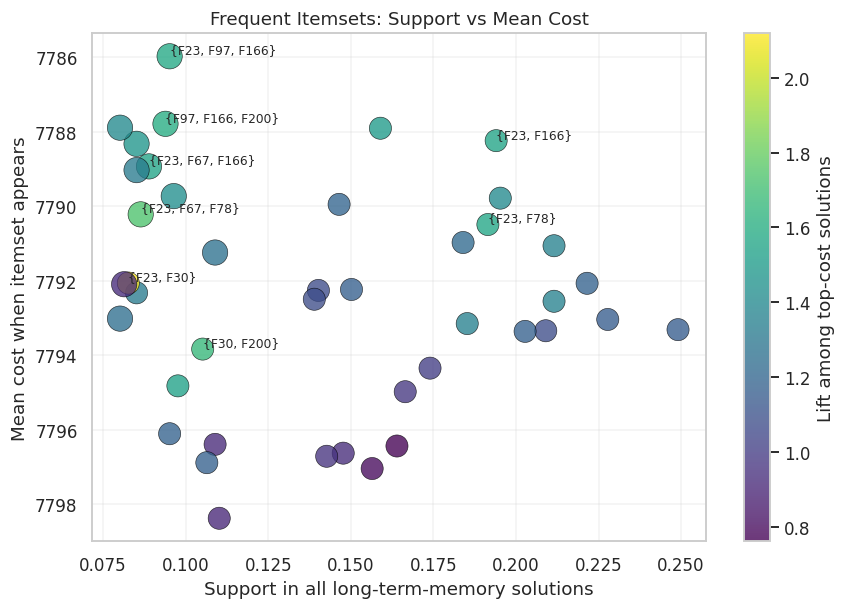

In [13]:
plot_df = itemsets_df[itemsets_df['size'] >= 2].copy()

if plot_df.empty:
    print('No multi-facility itemsets were found. Lower MIN_SUPPORT to inspect rarer patterns.')
else:
    fig, ax = plt.subplots(figsize=(9, 6))

    sizes = 80 + 260 * plot_df['size'] / MAX_ITEMSET_SIZE

    scatter = ax.scatter(
        plot_df  ['support'  ],
        plot_df  ['mean_cost'],
        c=plot_df['best_lift'],

        s        =sizes    ,
        cmap     ='viridis',
        edgecolor='black'  ,
        alpha    =0.78     ,
        linewidth=0.4      ,
    )

    for _, row in plot_df.sort_values('best_lift', ascending=False).head(8).iterrows():
        ax.text(
            row['support'  ],
            row['mean_cost'],
            row['label'    ],
            fontsize=8      ,
            ha     ='left'  ,
            va     ='bottom',
        )

    ax.set_title ('Frequent Itemsets: Support vs Mean Cost'  )
    ax.set_xlabel('Support in all long-term-memory solutions')
    ax.set_ylabel('Mean cost when itemset appears')

    ax.invert_yaxis()
    ax.grid(alpha=0.25)

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label     ('Lift among top-cost solutions')

    plt.show()

### ITEMSET INTERACTION GRAPH

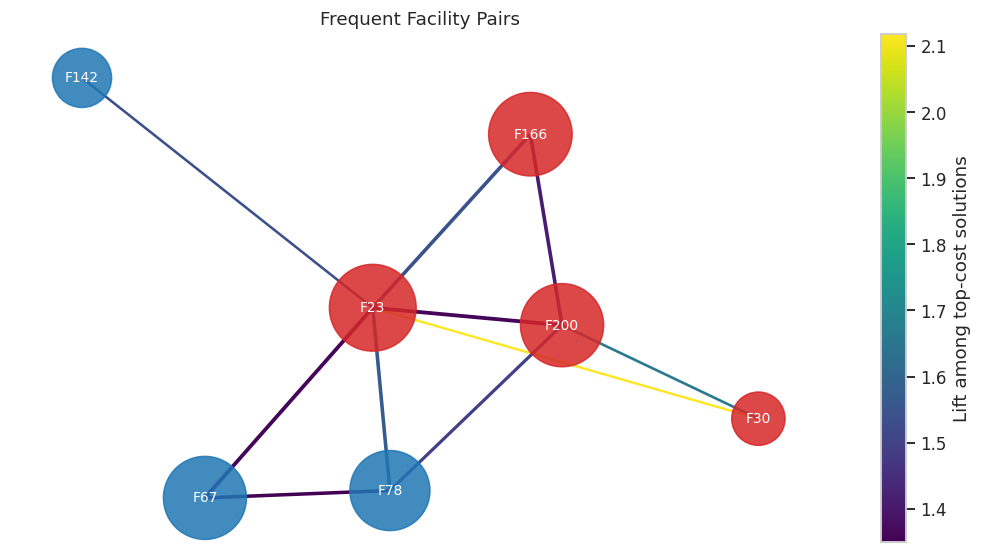

In [14]:
pair_df = itemsets_df[itemsets_df['size'] == 2].sort_values(
    ['best_lift', 'support'], ascending=False
).head(10)

if pair_df.empty:
    print('No frequent pairs were found. Lower MIN_SUPPORT to inspect rarer interactions.')
else:
    graph = nx.Graph()

    for _, row in pair_df.iterrows():
        left, right = sorted(row['itemset'])

        graph.add_node(left , count=int(facility_counts[left ]))
        graph.add_node(right, count=int(facility_counts[right]))
        graph.add_edge(
            left ,
            right,
            support  =row['support'  ],
            best_lift=row['best_lift'],
        )

    pos = nx.spring_layout(graph, seed=42, weight='support')

    node_sizes = [
        120 + 8 * graph.nodes[node]['count']
        for node in graph.nodes
    ]
    edge_widths = [
        1.0 + 7.0 * graph.edges[edge]['support']
        for edge in graph.edges
    ]
    edge_colors = [
        graph.edges[edge]['best_lift']
        for edge in graph.edges
    ]


    fig, ax = plt.subplots(figsize=(12, 6))

    nx.draw_networkx_nodes(
        graph,
        pos  ,
        node_size =node_sizes,
        node_color=['tab:red' if node in best_facilities else 'tab:blue' for node in graph.nodes],
        alpha=0.85,
        ax   =ax  ,
    )

    edges = nx.draw_networkx_edges(
        graph,
        pos  ,
        width     =edge_widths   ,
        edge_color=edge_colors   ,
        edge_cmap =plt.cm.viridis,
        ax=ax,
    )

    nx.draw_networkx_labels(
        graph,
        pos  ,
        labels={node: f'F{node}' for node in graph.nodes},
        font_size =9      ,
        font_color='white',
        ax=ax,
    )

    ax.set_title('Frequent Facility Pairs')
    ax.axis     ('off')

    cbar = plt.colorbar(edges, ax=ax)
    cbar.set_label     ('Lift among top-cost solutions')

    plt.show()

### ITEMSETS OVER COST-ORDERED SOLUTIONS

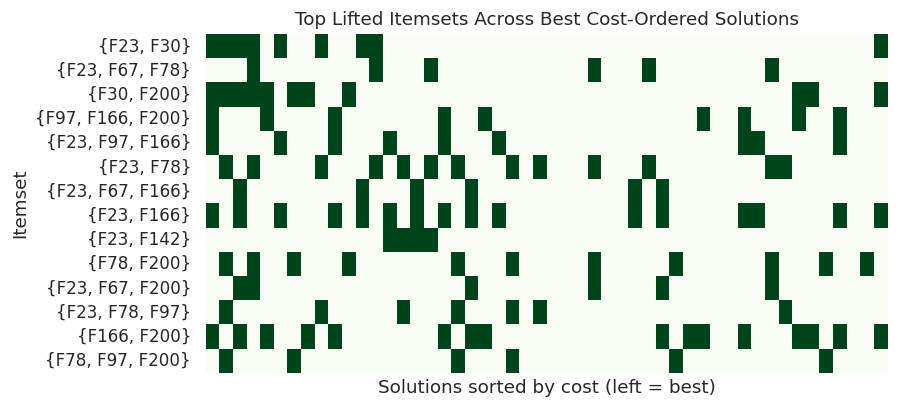

In [15]:
top_lifted = itemsets_df[itemsets_df['size'] >= 2].sort_values(
    ['best_lift', 'support'], ascending=False
).head(14)

if top_lifted.empty:
    print('No multi-facility itemsets were found. Lower MIN_SUPPORT to inspect rarer patterns.')
else:
    solution_window = min(50, len(X))

    heatmap_matrix = np.vstack(
        [
            itemset_mask(X, itemset)[:solution_window]
            for itemset in top_lifted['itemset']
        ]
    )


    fig, ax = plt.subplots(figsize=(8, 4))

    sns.heatmap(
        heatmap_matrix,
        cmap='Greens',
        cbar=False   ,
        yticklabels=top_lifted['label'],
        xticklabels=False              ,
        ax=ax,
    )

    ax.set_title ('Top Lifted Itemsets Across Best Cost-Ordered Solutions')
    ax.set_xlabel('Solutions sorted by cost (left = best)')
    ax.set_ylabel('Itemset'                               )

    plt.show()